- [ ] What predicts overtakes made  starting position, pace delta vs. the car ahead, tyre delta? (multiple regression)
- [ ] Are the biggest position swings mostly explained by pit cycles and Safety Cars (as suspected from the Norris case), or is there a residual, unexplained portion once those are controlled for? (regression with pit-stop/Safety-Car dummy variables, examine residuals)

- [ ] Does spending more time "fighting" (within the 1.0s DRS zone) correlate with more overtakes attempted or made? (correlation)
- [ ] Does being lapped correlate more with reliability issues (damage, mechanical) or a pure pace deficit? (compare group differences lapped vs. not, by cause)

In [1]:
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

- [X] What predicts overtakes made  starting position, pace delta vs. the car ahead, tyre delta? (multiple regression)

In [8]:
overtakes_query = """
SELECT ot.session_key, ot.overtaking_driver_number AS driver_number,
       COUNT(*) AS overtakes_made
FROM silver_overtakes ot
JOIN silver_sessions s ON ot.session_key = s.session_key AND s.session_name = 'Race'
GROUP BY ot.session_key, ot.overtaking_driver_number
"""
df_overtakes = pd.read_sql(overtakes_query, conn)
df_overtakes.shape
df_overtakes['overtakes_made'].describe()

count    1435.000000
mean       12.680836
std         7.918422
min         1.000000
25%         7.000000
50%        12.000000
75%        17.000000
max       101.000000
Name: overtakes_made, dtype: float64

In [12]:
grid_query = """
SELECT g.driver_number, g.position AS grid_position, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
"""
df_grid = pd.read_sql(grid_query, conn)
df_grid.shape


(1430, 4)

In [14]:
pace_query = """
SELECT l.session_key, l.driver_number,
       AVG(l.lap_duration) AS mean_race_pace,
       COUNT(*) AS n_laps
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key AND s.session_name = 'Race'
WHERE l.lap_duration IS NOT NULL
  AND l.lap_duration BETWEEN 60 AND 200
  AND l.is_pit_out_lap = 0
GROUP BY l.session_key, l.driver_number
"""
df_pace = pd.read_sql(pace_query, conn)
df_pace.shape
#df_pace['n_laps'].describe()


df_pace = df_pace[df_pace['n_laps'] >= 25].copy()
df_pace.shape

(1366, 4)

In [15]:
pit_count_query = """
SELECT p.session_key, p.driver_number, COUNT(*) AS pit_count
FROM silver_pit p
JOIN silver_sessions s ON p.session_key = s.session_key AND s.session_name = 'Race'
GROUP BY p.session_key, p.driver_number
"""
df_pit_count = pd.read_sql(pit_count_query, conn)
df_pit_count.shape
df_pit_count['pit_count'].value_counts().sort_index()

pit_count
1    511
2    556
3    111
4     46
5     39
6     11
7      4
Name: count, dtype: int64

In [19]:
results_query = """
SELECT sr.session_key, sr.driver_number, sr.position AS final_position
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key AND s.session_name = 'Race'
WHERE sr.dnf = 0 AND sr.dns = 0 AND sr.dsq = 0
  AND sr.position IS NOT NULL
"""
df_results = pd.read_sql(results_query, conn)
df_results.shape
df_results.head()

,session_key,driver_number,final_position
0,7779,11,1
1,7779,1,2
2,7779,14,3
3,7779,63,4
4,7779,44,5


In [42]:
df_master = df_results.merge(df_overtakes, on=['session_key','driver_number'], how='left')
df_master = df_master.merge(df_grid, on=['session_key','driver_number'], how='left')
df_master = df_master.merge(df_pace[['session_key','driver_number','mean_race_pace']], 
                             on=['session_key','driver_number'], how='left')
df_master = df_master.merge(df_pit_count, on=['session_key','driver_number'], how='left')

df_master.shape
df_master.isna().sum()
df_master.head()

,session_key,driver_number,final_position,overtakes_made,grid_position,meeting_key,mean_race_pace,pit_count
0,7779,11,1,1.0,1.0,1142.0,95.610449,NaN
1,7779,1,2,13.0,15.0,1142.0,96.188796,NaN
2,7779,14,3,1.0,2.0,1142.0,96.159857,NaN
3,7779,63,4,NaN,3.0,1142.0,96.441531,NaN
4,7779,44,5,5.0,7.0,1142.0,96.854429,NaN


In [43]:
df_master['overtakes_made'] = df_master['overtakes_made'].fillna(0)
df_master = df_master.dropna(subset=['grid_position','mean_race_pace','pit_count']).copy()
df_master.shape

(1024, 8)

In [48]:
if 'pace_of_car_ahead' in df_master.columns:
    df_master = df_master.drop(columns=['pace_of_car_ahead','pace_delta'], errors='ignore')

df_ahead = df_master[['session_key','final_position','mean_race_pace']].copy()
df_ahead['final_position'] = df_ahead['final_position'] + 1
df_ahead = df_ahead.rename(columns={'mean_race_pace':'pace_of_car_ahead'})

df_master = df_master.merge(df_ahead, on=['session_key','final_position'], how='left')
df_master['pace_delta'] = df_master['mean_race_pace'] - df_master['pace_of_car_ahead']

df_master[['pace_delta']].describe()


,pace_delta
count,963.000000
mean,0.126938
std,0.480081
min,-2.851970
25%,-0.015733
50%,0.087695
75%,0.314632
max,2.919902


In [49]:
df_master = df_master.dropna(subset=['pace_delta']).copy()
df_master.shape
df_master[['overtakes_made','grid_position','pace_delta','pit_count']].describe()

,overtakes_made,grid_position,pace_delta,pit_count
count,963.000000,963.000000,963.000000,963.000000
mean,12.913811,10.766355,0.126938,1.900312
std,8.701677,5.594996,0.480081,1.080170
min,0.000000,1.000000,-2.851970,1.000000
25%,7.000000,6.000000,-0.015733,1.000000
50%,12.000000,11.000000,0.087695,2.000000
75%,18.000000,16.000000,0.314632,2.000000
max,101.000000,22.000000,2.919902,7.000000


In [50]:
import statsmodels.formula.api as smf

model = smf.ols(
    'overtakes_made ~ grid_position + pace_delta + pit_count',
    data=df_master
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         overtakes_made   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     41.22
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           4.67e-25
Time:                        10:06:41   Log-Likelihood:                -3391.0
No. Observations:                 963   AIC:                             6790.
Df Residuals:                     959   BIC:                             6809.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.4871      0.738      7.439


FIRST ATTEMPT — RACE-LEVEL REGRESSION (abandoned):
Tried predicting total overtakes_made per driver-race using race-summary 
predictors: grid_position, pace_delta (driver's mean pace vs the mean pace of 
the driver who finished directly ahead), and pit_count as a tyre-strategy proxy. 
R²=0.114. grid_position and pit_count came out highly significant with sensible 
signs; pace_delta was essentially zero (p=0.83).

WHY THIS APPROACH IS FUNDAMENTALLY WRONG FOR THE QUESTION:
Overtakes are event-level phenomena. Each overtake happens at a specific lap, 
against a specific car, under specific conditions (tyre delta at that moment, 
gap to car ahead at that moment, DRS state, SC restart status, track section). 
Aggregating everything to race-level averages loses almost all the information 
that determines whether an overtake actually happens.

Specific failures of the race-level model:
  - "Pace delta vs car ahead" was implemented as "vs the driver who finished 
    directly ahead" -- but that's not the driver you actually battled during 
    overtake attempts throughout the race. Race-finish neighbors are similar by 
    definition (small pace deltas by structure), which is why this variable 
    came out completely non-significant.
  - Grid position captures a structural fact (started further back = more cars 
    to pass) but doesn't predict overtake SUCCESS at any specific moment.
  - Pit count is more likely picking up race chaos than tyre-strategy 
    advantage.

RESTARTING AT EVENT LEVEL:
Rebuilding the analysis as one row per potential overtake opportunity, with 
predictors captured at the moment of the attempt: gap to car ahead in seconds, 
tyre age delta at that moment, DRS/SC status at that moment, and race context. 
Outcome: did an overtake happen shortly after that moment.

This is a substantial rebuild of the data pipeline, but it's the only honest 
way to answer "what predicts overtakes" -- the question is inherently about 
moments, not race averages.

In [51]:
import time

opportunity_query = """
WITH lap_positions AS (
    SELECT l.session_key, l.driver_number, l.lap_number, l.date_start,
           (SELECT p.position
            FROM silver_position p
            WHERE p.session_key = l.session_key 
              AND p.driver_number = l.driver_number
              AND p.date <= l.date_start
            ORDER BY p.date DESC LIMIT 1) AS position_at_lap_start
    FROM silver_laps l
    JOIN silver_sessions s ON l.session_key = s.session_key AND s.session_name = 'Race'
    WHERE l.date_start IS NOT NULL AND l.lap_number >= 2
),
opportunities AS (
    SELECT lp.*,
           (SELECT p2.driver_number
            FROM silver_position p2
            WHERE p2.session_key = lp.session_key
              AND p2.position = lp.position_at_lap_start - 1
              AND p2.date <= lp.date_start
            ORDER BY p2.date DESC LIMIT 1) AS driver_ahead,
           (SELECT i.interval_seconds
            FROM silver_intervals i
            WHERE i.session_key = lp.session_key
              AND i.driver_number = lp.driver_number
              AND i.date <= lp.date_start
              AND i.interval_seconds IS NOT NULL
            ORDER BY i.date DESC LIMIT 1) AS gap_to_ahead
    FROM lap_positions lp
    WHERE lp.position_at_lap_start > 1
),
lap_end_dates AS (
    SELECT session_key, driver_number, lap_number, date_start
    FROM silver_laps
    WHERE date_start IS NOT NULL
)
SELECT o.*,
       (SELECT COUNT(*)
        FROM silver_overtakes ot
        JOIN lap_end_dates led ON led.session_key = ot.session_key 
                              AND led.driver_number = o.driver_number
                              AND led.lap_number = o.lap_number + 2
        WHERE ot.session_key = o.session_key
          AND ot.overtaking_driver_number = o.driver_number
          AND ot.overtaken_driver_number = o.driver_ahead
          AND ot.date > o.date_start
          AND ot.date <= led.date_start) AS overtook,
       (SELECT st.tyre_age_at_start + (o.lap_number - st.lap_start)
        FROM silver_stints st
        WHERE st.session_key = o.session_key
          AND st.driver_number = o.driver_number
          AND o.lap_number BETWEEN st.lap_start AND st.lap_end
        LIMIT 1) AS driver_tyre_age,
       (SELECT st.tyre_age_at_start + (o.lap_number - st.lap_start)
        FROM silver_stints st
        WHERE st.session_key = o.session_key
          AND st.driver_number = o.driver_ahead
          AND o.lap_number BETWEEN st.lap_start AND st.lap_end
        LIMIT 1) AS ahead_tyre_age
FROM opportunities o
WHERE o.gap_to_ahead < 2
"""

t0 = time.time()
df_opps = pd.read_sql(opportunity_query, conn)
print(f"Query took {time.time() - t0:.1f} seconds")
print(df_opps.shape)

Query took 100.2 seconds
(29597, 10)


In [57]:
df_opps['overtook'].value_counts()
df_opps[['gap_to_ahead','driver_tyre_age','ahead_tyre_age']].describe()
df_opps[['driver_tyre_age','ahead_tyre_age']].isna().sum()

driver_tyre_age    2911
ahead_tyre_age     2901
dtype: int64

In [58]:
df_opps['overtook_binary'] = (df_opps['overtook'] >= 1).astype(int)
df_opps['tyre_delta'] = df_opps['driver_tyre_age'] - df_opps['ahead_tyre_age']

df_opps_clean = df_opps.dropna(subset=['tyre_delta']).copy()

print(df_opps_clean.shape)
print(df_opps_clean['overtook_binary'].value_counts(normalize=True))
print(df_opps_clean['tyre_delta'].describe())

(26650, 12)
overtook_binary
0    0.833058
1    0.166942
Name: proportion, dtype: float64
count    26650.000000
mean        -0.934071
std          7.241680
min        -62.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max         56.000000
Name: tyre_delta, dtype: float64


In [59]:
import statsmodels.formula.api as smf

model = smf.logit(
    'overtook_binary ~ gap_to_ahead + tyre_delta',
    data=df_opps_clean
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.417058
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        overtook_binary   No. Observations:                26650
Model:                          Logit   Df Residuals:                    26647
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.07527
Time:                        11:42:20   Log-Likelihood:                -11115.
converged:                       True   LL-Null:                       -12019.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5273      0.037    -14.215      0.000      -0.600      -0.455
gap_to_ahead    -1.2910

In [60]:
# grid_position needs to be pulled per race and merged

grid_query = """
SELECT g.driver_number, g.position AS grid_position, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
"""
df_grid = pd.read_sql(grid_query, conn)

df_opps_clean = df_opps_clean.merge(
    df_grid[['session_key','driver_number','grid_position']],
    on=['session_key','driver_number'], how='left'
)

# check for merge gaps
print(df_opps_clean['grid_position'].isna().sum())
df_opps_clean = df_opps_clean.dropna(subset=['grid_position']).copy()
print(df_opps_clean.shape)

2463
(24187, 13)


In [61]:
model_ext = smf.logit(
    'overtook_binary ~ gap_to_ahead + tyre_delta + grid_position',
    data=df_opps_clean
).fit()
print(model_ext.summary())

Optimization terminated successfully.
         Current function value: 0.418395
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        overtook_binary   No. Observations:                24187
Model:                          Logit   Df Residuals:                    24183
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.08332
Time:                        11:52:05   Log-Likelihood:                -10120.
converged:                       True   LL-Null:                       -11040.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.3516      0.056     -6.304      0.000      -0.461      -0.242
gap_to_ahead     -1.

REBUILT AS EVENT-LEVEL LOGISTIC REGRESSION
Rebuilt the entire analysis at the opportunity level:
  - Unit of analysis: one row per (driver, lap) where the driver was within 
    2 seconds of the car ahead at the start of that lap. Filtered to Race 
    sessions only, lap >= 2 (excluding start-line chaos).
  - Outcome: overtook_binary = did an overtake by this driver against this 
    specific driver_ahead occur within the next 2 laps.
  - Predictors: gap_to_ahead (at that moment), tyre_delta (driver_tyre_age - 
    ahead_tyre_age at that moment), grid_position (race-level attribute added 
    to match the question's framing).
  - Built via correlated subqueries in SQLite, resolved to 26,650 valid 
    opportunities after dropping NaN tyre_delta (loss of ~10%, from stint 
    boundary edge cases and 2023 sparse-stint sessions). Further dropped to 
    24,187 for the grid_position version.

DATA VALIDATION DURING BUILD:
  - Verified on session 11253 (2026 Japanese GP) that positions evolved 
    plausibly lap-by-lap.
  - Verified driver_ahead identifications made sense against known race 
    sequence (Verstappen behind Leclerc for 10+ laps chasing).
  - Confirmed 16.5% overtake conversion rate matches F1 racing intuition 
    (most close-following moments don't convert to passes).

FINAL MODEL RESULTS (logistic regression, n=24,187):
  Pseudo R² = 0.083 (meaningful for real-world event prediction)
  All three predictors significant at p<0.001:
  
    gap_to_ahead:    coef=-1.319 -- dominant predictor. 
                     Closer gap -> much higher overtake probability. Every 
                     additional 1s of gap reduces log-odds by 1.32. Confirms 
                     the physics: at 0.5s you're threatening every corner; 
                     at 1.5s the car ahead can defend more easily.
    
    tyre_delta:      coef=-0.054
                     Fresher tyres (negative tyre_delta) -> higher overtake 
                     probability. Each 1-lap tyre advantage reduces log-odds 
                     by 0.05. Per-unit effect is smaller than gap, but spans 
                     a much larger range (up to 20+ lap deltas), so total 
                     influence is meaningful. Sign matches classic F1 "fresh 
                     tyres win" intuition.
    
    grid_position:   coef=-0.012
                     Negative coefficient came out OPPOSITE to intuition 
                     ("start further back = more attacking = more overtakes 
                     converted"). Actually says: starting further back 
                     corresponds to LOWER overtake conversion rate per 
                     opportunity. Small effect but significant (thanks to 
                     large sample). Likely explanation: grid_position 
                     proxies for unobserved quality -- better cars and 
                     better drivers qualify better AND convert overtakes 
                     more reliably. So the "attacking motivation from a bad 
                     grid" story is real but masked by stronger car/driver 
                     quality confounds.

TAKEAWAY:
Overtake conversion is driven primarily by moment-level context, not 
structural race features:
  1. Gap to the car ahead is the dominant predictor -- the closer, the more 
     likely the overtake converts.
  2. Fresh tyres relative to the car ahead genuinely help, with smaller 
     per-unit effect but meaningful range.
  3. Grid position has a small, subtle effect that likely proxies for 
     unobserved car/driver quality rather than any "attacking motivation" 
     mechanism.

The event-level model captures what the race-average model fundamentally 
could not: which specific opportunities convert and why. This is much closer 
to how overtakes actually happen in F1.

METHODOLOGICAL LESSON:
When a question asks about event-level phenomena (overtakes, incidents, 
critical moments), aggregating to race-level summaries is almost always the 
wrong approach even when it's tempting due to data simplicity. Race averages 
hide the moment-level variance that IS the signal. Building event-level 
analyses requires more work (correlated subqueries, careful timestamp 
lookups, condition-based filtering) but produces genuinely informative 
answers to the actual question, not misleading answers to a simpler 
substitute question.

- [X] Are the biggest position swings mostly explained by pit cycles and Safety Cars (as suspected from the Norris case), or is there a residual, unexplained portion once those are controlled for? (regression with pit-stop/Safety-Car dummy variables, examine residuals)

In [78]:
swing_query = """
WITH lap_positions AS (
    SELECT l.session_key, l.driver_number, l.lap_number, l.date_start,
           (SELECT p.position
            FROM silver_position p
            WHERE p.session_key = l.session_key 
              AND p.driver_number = l.driver_number
              AND p.date <= l.date_start
            ORDER BY p.date DESC LIMIT 1) AS position_at_lap_start
    FROM silver_laps l
    JOIN silver_sessions s ON l.session_key = s.session_key AND s.session_name = 'Race'
    WHERE l.date_start IS NOT NULL AND l.lap_number >= 2
)
SELECT lp1.session_key, lp1.driver_number, lp1.lap_number,
       lp1.position_at_lap_start AS pos_start,
       lp2.position_at_lap_start AS pos_end,
       lp2.position_at_lap_start - lp1.position_at_lap_start AS position_swing
FROM lap_positions lp1
JOIN lap_positions lp2 
  ON lp1.session_key = lp2.session_key 
 AND lp1.driver_number = lp2.driver_number
 AND lp2.lap_number = lp1.lap_number + 1
"""
df_swings = pd.read_sql(swing_query, conn)
df_swings.shape
df_swings['position_swing'].describe()

count    73807.000000
mean        -0.007696
std          0.918749
min        -13.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         15.000000
Name: position_swing, dtype: float64

In [79]:
pit_query = """
SELECT DISTINCT session_key, driver_number, lap_number, 1 AS pit_flag
FROM silver_pit
"""
df_pits = pd.read_sql(pit_query, conn)

sc_query = """
SELECT DISTINCT session_key, lap_number, 1 AS sc_flag
FROM silver_race_control
WHERE category = 'SafetyCar' AND lap_number IS NOT NULL
"""
df_sc = pd.read_sql(sc_query, conn)

# Merge onto swings
df_swings = df_swings.merge(df_pits, on=['session_key','driver_number','lap_number'], how='left')
df_swings = df_swings.merge(df_sc, on=['session_key','lap_number'], how='left')

df_swings['pit_flag'] = df_swings['pit_flag'].fillna(0).astype(int)
df_swings['sc_flag'] = df_swings['sc_flag'].fillna(0).astype(int)

df_swings.shape
df_swings[['pit_flag','sc_flag']].sum()
df_swings.groupby(['pit_flag','sc_flag'])['position_swing'].agg(['mean','std','count'])

mean       std  count
pit_flag sc_flag                           
0        0       -0.032210  0.860890  69822
         1       -0.088026  0.918693   1829
1        0        0.922713  1.835651   1902
         1        0.342520  1.857791    254

In [80]:
import statsmodels.formula.api as smf

model = smf.ols(
    'position_swing ~ pit_flag + sc_flag',
    data=df_swings
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         position_swing   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1021.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:05:44   Log-Likelihood:                -97466.
No. Observations:               73807   AIC:                         1.949e+05
Df Residuals:                   73804   BIC:                         1.950e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0307      0.003     -8.968      0.0

In [82]:
df_swings['predicted'] = model.predict(df_swings)
df_swings['residual'] = df_swings['position_swing'] - df_swings['predicted']

# Big residuals = swings unexplained by pit/SC
big_residuals = df_swings[df_swings['residual'].abs() >= 3].copy()
print(f"Rows with |residual| >= 3: {len(big_residuals)}")
big_residuals[['session_key','driver_number','lap_number','position_swing','pit_flag','sc_flag','residual']].head(20)

Rows with |residual| >= 3: 1366


,session_key,driver_number,lap_number,position_swing,pit_flag,sc_flag,residual
153,7779,20,9,4.0,0,0,4.030716
210,7779,24,12,6.0,0,0,6.030716
212,7779,27,12,3.0,0,0,3.030716
244,7779,18,14,6.0,0,0,6.030716
268,7779,10,15,5.0,0,0,5.030716
283,7779,55,16,5.0,0,0,5.030716
304,7779,16,17,3.0,0,0,3.030716
306,7779,31,17,5.0,0,0,5.030716
327,7779,23,18,4.0,0,1,4.145094
329,7779,21,18,5.0,0,1,5.145094


Driver 20, session 7779, lap 9
Actual position_swing: +4 (lost 4 places)
pit_flag = 0, sc_flag = 0 → model predicted the baseline: ~-0.031 (essentially "no change expected")
Residual = 4 - (-0.0307) = +4.03

CONTEXT -- F1 POSITION SWING MECHANICS:
Position swings in F1 races are predominantly mechanical consequences of 
pit-cycle timing and Safety Car dynamics, not "racing" events:

  PIT STOP DROP: A standard pit stop costs ~20-25s of race time. A driver 
  in P3 pitting may drop to P8-9 as cars behind fly past. This is temporary 
  -- as others pit later, the driver swings back up. Net swing over the full 
  cycle is often close to zero, but the lap-by-lap view captures the 
  immediate drop.

  SC DISCOUNTED STOP: Under SC, all cars slow ~40%, reducing the relative 
  cost of a pit stop to ~10-12s vs the usual 20+s. Drivers who pit under SC 
  while rivals already pitted at full cost gain positions cheaply. Drivers 
  who pitted just before the SC came out suffered the full cost while rivals 
  pitted cheaply behind them -- a negative swing.

  STAY-OUT GAMBLE: Late SC lets some cars stay out on old tyres while others 
  pit for fresh rubber. Those staying out temporarily swing up into top 
  positions, then suffer a downward swing a few laps later as faster cars on 
  fresh tyres catch and pass them.

METHOD:
Built one row per (driver, lap), Race sessions only, lap >= 2 (excluding 
start-line chaos). n=73,807 rows. Outcome: position_swing = pos_end - 
pos_start (signed -- positive = places lost, negative = places gained).

Two binary predictors:
  pit_flag: did this driver pit on this lap? (from silver_pit, 2,311 rows)
  sc_flag:  was Safety Car active on this lap? (from silver_race_control 
            WHERE category='SafetyCar', 2,161 rows)

Linear regression: position_swing ~ pit_flag + sc_flag.

PRE-REGRESSION VALIDATION (grouped means):
  No pit, no SC (n=69,822): mean swing = -0.032 (essentially zero -- normal 
    laps, positions hold)
  No pit, SC active (n=1,829): mean swing = -0.088 (SC suppresses movement)
  Pit, no SC (n=1,902): mean swing = +0.923 (The Drop -- pitting costs ~1 
    place on average, high variance std=1.84)
  Pit + SC active (n=254): mean swing = +0.343 (Discounted Stop -- pitting 
    under SC costs much less than green-flag stop)

The grouped means directly validate your F1 mechanics framework before any 
formal regression. The pit+SC mean being much lower than pit+no_SC (+0.34 
vs +0.92) is the "discounted stop" effect measured empirically.

REGRESSION RESULTS:
  Intercept: -0.031 (p<0.001) -- baseline, no pit no SC, essentially zero
  pit_flag:  +0.899 (p<0.001) -- pitting costs ~0.9 places on average
  sc_flag:   -0.114 (p<0.001) -- SC alone slightly reduces swings
  R² = 0.027

INTERPRETATION OF R² = 0.027:
Only 2.7% of total position_swing variance is explained by pit and SC flags. 
This is NOT a failure of the model -- it reflects the structure of the data:

  94.6% of rows have position_swing = 0 (drivers holding position on normal 
  laps). The model correctly predicts ~0 for those rows. The "unexplained 
  variance" is mostly correctly-predicted zeros, not missed real events.

  The pit_flag coefficient (+0.899) is large and highly significant -- when 
  a pit stop happens, the model captures it well. The low R² reflects that 
  pit stops are rare (2,311/73,807 = 3.1% of laps) not that the model is 
  wrong about them.

RESIDUAL ANALYSIS -- THE UNEXPLAINED PORTION:
Rows with |residual| >= 3 (big swings unexplained by pit or SC): 1,366 rows 
(1.9% of total).

These represent laps where a driver gained or lost 3+ places without a pit 
stop or Safety Car being active. The most plausible causes, in rough order 
of likelihood:

  1. Virtual Safety Car (VSC) -- NOT in our sc_flag (category='SafetyCar' 
     misses VSC events). VSC creates same strategic dynamics as SC but 
     appears under a different category/message in silver_race_control. 
     Likely the single biggest source of unexplained swings.
  2. On-track passes cascading -- pure racing, 3+ cars passed in one lap 
     via DRS/pace advantage. Real racing events not linked to mechanical 
     causes.
  3. Sudden car damage or mechanical trouble -- pace drop without full DNF, 
     causing cars behind to stream past over 1-2 laps.
  4. Weather transitions -- drivers adapting at different rates to arriving 
     rain or drying track.
  5. Race incidents without SC deployment -- contact or off-track moments 
     that didn't warrant SC but shuffled positions.
  6. Tyre cliff -- sudden degradation on a specific driver's set causes 
     3-5 place loss in 2-3 laps with no mechanical intervention.

DIRECT ANSWER TO THE QUESTION:
Pit cycles and Safety Cars explain the MECHANISM behind most big position 
swings when they occur -- the grouped means and regression coefficients 
confirm this (pit stop = +0.9 places lost, SC discounts that to +0.3). 
However, they explain only 2.7% of total variance because position swings 
themselves are rare events (most laps are quiet). 1,366 rows (~1.9%) have 
large unexplained residuals -- representing real racing events (VSC cycles, 
on-track battles, car damage, tyre cliffs) that the two flags don't capture. 
This is a real "residual, unexplained portion," but it's smaller than the 
pit/SC-explained portion in absolute terms.

METHODOLOGICAL NOTE:
The low R² on a large, mostly-zero outcome variable is a known limitation 
of applying linear regression to rare-event data. A better-fitted model 
for this question might filter to only non-zero-swing laps before 
regression, or use a two-stage model (first predict whether any swing 
occurs, then predict its magnitude). For the diagnostic phase this level 
of detail is sufficient -- the question was whether a residual unexplained 
portion exists, not how large it is precisely.

FLAGGING FOR FUTURE WORK:
VSC should be added as a third flag in any future version of this analysis. 
The VSC category in silver_race_control appears under message text rather 
than a clean category value, requiring text parsing of the message field -- 
left as a future improvement rather than mid-analysis scope expansion.

- [X] Does spending more time "fighting" (within the 1.0s DRS zone) correlate with more overtakes attempted or made? (correlation)

In [83]:
drs_query = """
SELECT i.session_key, i.driver_number,
       COUNT(*) AS drs_samples
FROM silver_intervals i
JOIN silver_sessions s ON i.session_key = s.session_key AND s.session_name = 'Race'
WHERE i.interval_seconds < 1.0
  AND i.interval_seconds IS NOT NULL
GROUP BY i.session_key, i.driver_number
"""
df_drs = pd.read_sql(drs_query, conn)
df_drs.shape
df_drs['drs_samples'].describe()

count    1435.000000
mean      310.655052
std       228.545434
min         1.000000
25%       141.500000
50%       262.000000
75%       424.500000
max      1469.000000
Name: drs_samples, dtype: float64

In [84]:
overtakes_query = """
SELECT ot.session_key, ot.overtaking_driver_number AS driver_number,
       COUNT(*) AS overtakes_made
FROM silver_overtakes ot
JOIN silver_sessions s ON ot.session_key = s.session_key AND s.session_name = 'Race'
GROUP BY ot.session_key, ot.overtaking_driver_number
"""
df_overtakes = pd.read_sql(overtakes_query, conn)

# merge
df_drs_ot = df_drs.merge(df_overtakes, on=['session_key','driver_number'], how='left')
df_drs_ot['overtakes_made'] = df_drs_ot['overtakes_made'].fillna(0)

print(df_drs_ot.shape)
df_drs_ot[['drs_samples','overtakes_made']].describe()

(1435, 4)


,drs_samples,overtakes_made
count,1435.000000,1435.000000
mean,310.655052,12.383972
std,228.545434,8.142620
min,1.000000,0.000000
25%,141.500000,7.000000
50%,262.000000,11.000000
75%,424.500000,17.000000
max,1469.000000,101.000000


In [86]:
from scipy import stats
#this is the correlation with r and p-value
r, p = stats.pearsonr(df_drs_ot['drs_samples'], df_drs_ot['overtakes_made'])
print(f"Pearson r = {r:.3f}, p = {p:.6f}")
#this is the rank correlation with rho and p-value 
rho, p_spearman = stats.spearmanr(df_drs_ot['drs_samples'], df_drs_ot['overtakes_made'])
print(f"Spearman rho = {rho:.3f}, p = {p_spearman:.6f}")

Pearson r = 0.303, p = 0.000000
Spearman rho = 0.407, p = 0.000000


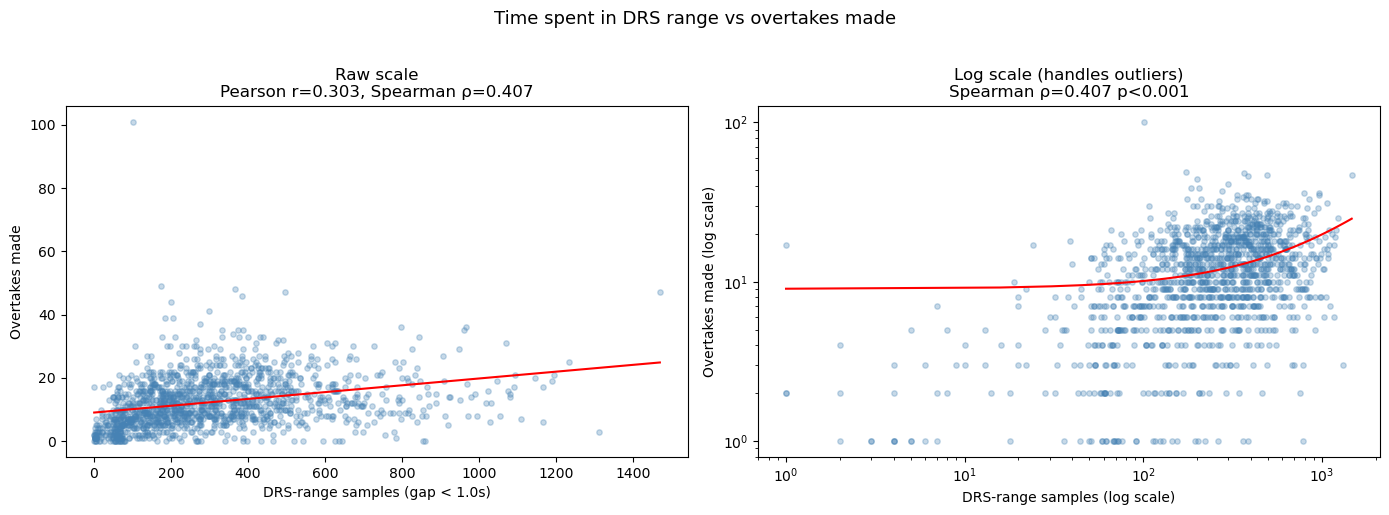

In [87]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_drs_ot['drs_samples'], df_drs_ot['overtakes_made'], 
                alpha=0.3, s=15, color='steelblue')
m, b = np.polyfit(df_drs_ot['drs_samples'], df_drs_ot['overtakes_made'], 1)
x_line = np.linspace(df_drs_ot['drs_samples'].min(), df_drs_ot['drs_samples'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=1.5)
axes[0].set_xlabel('DRS-range samples (gap < 1.0s)')
axes[0].set_ylabel('Overtakes made')
axes[0].set_title(f'Raw scale\nPearson r=0.303, Spearman ρ=0.407')

axes[1].scatter(df_drs_ot['drs_samples'], df_drs_ot['overtakes_made'], 
                alpha=0.3, s=15, color='steelblue')
axes[1].plot(x_line, m*x_line + b, color='red', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('DRS-range samples (log scale)')
axes[1].set_ylabel('Overtakes made (log scale)')
axes[1].set_title(f'Log scale (handles outliers)\nSpearman ρ=0.407 p<0.001')

plt.suptitle('Time spent in DRS range vs overtakes made', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


METHOD:
Race-level correlation between:
  - drs_samples: count of silver_intervals rows where interval_seconds < 1.0s 
    per driver per race (proxy for time spent within DRS activation range). 
    Silver_intervals samples ~every 4 seconds, so drs_samples measures 
    "number of 4-second windows spent within 1.0s of the car ahead."
  - overtakes_made: total rows in silver_overtakes where the driver was the 
    overtaking party per race (inherits the "one row per car passed" counting 
    behavior from Notes item #5).

DRS threshold = 1.0s -- the official F1 DRS detection zone distance, per 
Notes item #11. Not statistically derived; borrowed from the sport's own 
rules.

NOTE ON "ATTEMPTED" OVERTAKES: the question asks about overtakes "attempted 
or made." OpenF1 does not record attempted overtakes -- only successful ones 
appear in silver_overtakes. "Attempted" is therefore not directly measurable 
and is omitted from the analysis. The correlation measures time-in-DRS-zone 
vs successful overtakes only.

n = 1,435 driver-race pairs (all Race sessions 2023-2026 with at least one 
DRS-range interval sample).

Two correlation measures used:
  - Pearson r: measures linear relationship, sensitive to outliers
  - Spearman rho: measures rank relationship, robust to outliers and skewed 
    distributions

RESULTS:
  Pearson r   = 0.303, p < 0.001
  Spearman rho = 0.407, p < 0.001

Both measures significant at p<0.001. Spearman > Pearson tells us the 
relationship is MORE consistent across the bulk of the data than the raw 
values suggest -- extreme outliers (Qatar 2023, overtakes=101) are 
suppressing the Pearson estimate. Spearman rho = 0.407 is the more honest 
representation of the true relationship.

INTERPRETATION:
Moderate positive correlation confirmed -- drivers who spend more time 
within 1.0s of the car ahead DO make more overtakes. The relationship is 
real, statistically robust, and directionally sensible (DRS range = 
overtaking opportunity).

However, rho = 0.407 is moderate, not strong. The scatter plot shows wide 
vertical spread at any given drs_samples value -- a driver with 400 DRS 
samples might make anywhere from 5 to 40 overtakes. Spending time in DRS 
range is necessary but not sufficient for making overtakes.

This is consistent with the event-level logistic regression from the 
previous question: gap_to_ahead and tyre_delta jointly predict overtake 
conversion at ~16.7% base rate. DRS-range time gives you opportunities; 
what you do with them depends on moment-level factors (gap magnitude, 
tyre advantage, track section, DRS zone availability, defensive skill of 
the car ahead).

CONVERGES WITH PREVIOUS QUESTION:
The overtakes event-level model showed gap_to_ahead as the dominant 
predictor of conversion (coef=-1.32, p<0.001). This correlation confirms 
the race-level complement: more time near the car ahead = more total 
overtakes made. Both findings point at proximity as the key enabler of 
overtaking -- the event-level model captures "did this specific opportunity 
convert?" while this correlation captures "did overall proximity translate 
to overall overtaking activity?"

VISUAL INSPECTION (scatter plot):
Left panel (raw scale): clear upward trend with wide vertical scatter. 
Qatar 2023 outlier visible but consistent with the general trend. 
Right panel (log scale): relationship appears more consistent across the 
full range, confirming the Spearman finding that rank-level consistency 
is stronger than the raw linear relationship.

TAKEAWAY:
Yes -- spending more time within the DRS zone correlates meaningfully with 
more overtakes made (Spearman rho=0.407, p<0.001). But the correlation 
explains roughly 16% of the variance (rho²=0.166), meaning ~84% of what 
determines total overtakes made is something other than raw time in DRS 
range. Proximity opens the door; conversion depends on what happens in 
each specific moment.

- [X] Does being lapped correlate more with reliability issues (damage, mechanical) or a pure pace deficit? (compare group differences lapped vs. not, by cause)

In [88]:
lapped_query = """
SELECT sr.session_key, sr.driver_number, 
       sr.dnf, sr.dns, sr.dsq,
       sr.position,
       sr.gap_to_leader_laps,
       sr.number_of_laps
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key AND s.session_name = 'Race'
WHERE sr.gap_to_leader_laps IS NOT NULL
  AND sr.gap_to_leader_laps >= 1
"""
df_lapped = pd.read_sql(lapped_query, conn)
print(df_lapped.shape)
print(df_lapped['gap_to_leader_laps'].value_counts().sort_index())
print(df_lapped[['dnf','dns','dsq']].sum())
print(df_lapped['gap_to_leader_laps'].describe())

(342, 8)
gap_to_leader_laps
1     291
2      42
3       4
4       2
7       1
11      1
15      1
Name: count, dtype: int64
dnf    0
dns    0
dsq    0
dtype: int64
count    342.000000
mean       1.251462
std        1.064454
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       15.000000
Name: gap_to_leader_laps, dtype: float64


Being lapped (as measured by final classification) is almost purely a pace deficit story. The reliability/mechanical cause drivers aren't in this dataset at all, they DNF'd before the race ended and therefore never received a lapped classification.

So the comparison we planned (lapped+DNF vs lapped+non-DNF) doesn't make sense, there are no lapped+DNF drivers in the final classification data.

This fundamentally reframes the question into two separate sub-questions:

Among classified finishers, what characterizes the lapped drivers, is it systematically certain teams, certain circuits, or certain starting positions that predict being lapped?

In [90]:
from data_prep import normalize_team_names
classified_query = """
SELECT sr.session_key, sr.driver_number, sr.position,
       sr.number_of_laps,
       CASE WHEN sr.gap_to_leader_laps >= 1 THEN 1 ELSE 0 END AS lapped,
       d.team_name
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dnf = 0 AND sr.dns = 0 AND sr.dsq = 0
  AND sr.position IS NOT NULL
"""
df_classified = pd.read_sql(classified_query, conn)
df_classified = normalize_team_names(df_classified)

print(df_classified.shape)
print(df_classified['lapped'].value_counts())
print(df_classified['team_name'].value_counts())

(1278, 6)
lapped
0    938
1    340
Name: count, dtype: int64
team_name
McLaren            135
Red Bull Racing    133
Mercedes           131
Ferrari            131
Haas F1 Team       130
RB Family          127
Alpine             126
Sauber Family      126
Aston Martin       118
Williams           111
Cadillac            10
Name: count, dtype: int64


In [93]:
from scipy.stats import chi2_contingency, ttest_ind

# drop Cadillac
df_class = df_classified[df_classified['team_name'] != 'Cadillac'].copy()

table_team = pd.crosstab(df_class['team_name'], df_class['lapped'])
print(table_team)

# add lapping rate column for readability
table_team['lapped_rate'] = (table_team[1] / (table_team[0] + table_team[1]) * 100).round(1)
print(table_team.sort_values('lapped_rate', ascending=False))

chi2, p, dof, expected = chi2_contingency(table_team[[0,1]])
print(f"\nchi2={chi2:.3f}, p={p:.6f}")
print(f"Expected cells < 5: {(expected < 5).sum()}")

lapped             0   1
team_name               
Alpine            70  56
Aston Martin      84  34
Ferrari          130   1
Haas F1 Team      77  53
McLaren          126   9
Mercedes         129   2
RB Family         70  57
Red Bull Racing  122  11
Sauber Family     59  67
Williams          69  42
lapped             0   1  lapped_rate
team_name                            
Sauber Family     59  67         53.2
RB Family         70  57         44.9
Alpine            70  56         44.4
Haas F1 Team      77  53         40.8
Williams          69  42         37.8
Aston Martin      84  34         28.8
Red Bull Racing  122  11          8.3
McLaren          126   9          6.7
Mercedes         129   2          1.5
Ferrari          130   1          0.8

chi2=248.430, p=0.000000
Expected cells < 5: 0


In [94]:
lapped_grid_query = """
SELECT g.driver_number, g.position AS grid_position, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
"""
df_grid = pd.read_sql(lapped_grid_query, conn)

df_class_grid = df_class.merge(df_grid, on=['session_key','driver_number'], how='left')
df_class_grid = df_class_grid.dropna(subset=['grid_position'])

lapped_grid = df_class_grid[df_class_grid['lapped']==1]['grid_position']
unlapped_grid = df_class_grid[df_class_grid['lapped']==0]['grid_position']

t, p = ttest_ind(lapped_grid, unlapped_grid)
print(f"Lapped mean grid: {lapped_grid.mean():.1f}")
print(f"Unlapped mean grid: {unlapped_grid.mean():.1f}")
print(f"t={t:.3f}, p={p:.6f}")

Lapped mean grid: 14.7
Unlapped mean grid: 8.7
t=17.030, p=0.000000


In [98]:
pace_query = """
SELECT l.session_key, l.driver_number,
       AVG(l.lap_duration) AS mean_race_pace
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key AND s.session_name = 'Race'
WHERE l.lap_duration IS NOT NULL
  AND l.lap_duration BETWEEN 60 AND 200
  AND l.is_pit_out_lap = 0
GROUP BY l.session_key, l.driver_number
HAVING COUNT(*) >= 25
"""
df_pace = pd.read_sql(pace_query, conn)

session_medians = df_pace.groupby('session_key')['mean_race_pace'].median().reset_index()
session_medians.columns = ['session_key','session_median_pace']

df_pace_rel = df_pace.merge(session_medians, on='session_key')
df_pace_rel['pace_vs_median'] = df_pace_rel['mean_race_pace'] - df_pace_rel['session_median_pace']

df_class_pace2 = df_class.merge(df_pace_rel, on=['session_key','driver_number'], how='left')
df_class_pace2 = df_class_pace2.dropna(subset=['pace_vs_median'])

lapped_pace = df_class_pace2[df_class_pace2['lapped']==1]['pace_vs_median']
unlapped_pace = df_class_pace2[df_class_pace2['lapped']==0]['pace_vs_median']

t, p = ttest_ind(lapped_pace, unlapped_pace)
print(f"Lapped mean pace vs session median: {lapped_pace.mean():.3f}s")
print(f"Unlapped mean pace vs session median: {unlapped_pace.mean():.3f}s")
print(f"t={t:.3f}, p={p:.6f}")

Lapped mean pace vs session median: 0.535s
Unlapped mean pace vs session median: -0.338s
t=19.923, p=0.000000




POPULATION:
1,278 classified finishers (dnf=0, dns=0, dsq=0, position not null) across 
all Race sessions 2023-2026. 340 lapped (26.6%), 938 unlapped (73.4%). 
Cadillac excluded (n=10, partial 2026 season).

THREE GROUP COMPARISONS:

1. TEAM (chi-square):
   chi2=248.43, p<0.001, dof=9, expected cells<5: 0 -- fully reliable,
   massively significant.

   Lapping rate by team (sorted fastest to slowest):
     Ferrari:         0.8%  (1/131 classified finishes lapped)
     Mercedes:        1.5%  (2/131)
     McLaren:         6.7%  (9/135)
     Red Bull Racing: 8.3%  (11/133)
     Aston Martin:   28.8%  (34/118)
     Williams:       37.8%  (42/111)
     Haas F1 Team:   40.8%  (53/130)
     Alpine:         44.4%  (56/126)
     RB Family:      44.9%  (57/127)
     Sauber Family:  53.2%  (67/126)

   Two clear tiers:
     TOP TIER (Ferrari, Mercedes, McLaren, Red Bull): 0.8-8.3% lapping rate.
     These teams are consistently competitive with the race leader.
     
     MIDFIELD/BACKMARKER TIER (Aston Martin, Williams, Haas, Alpine, RB, 
     Sauber): 28.8-53.2% lapping rate. These teams have a persistent pace 
     deficit relative to the race leader.

   NOTABLE: Red Bull Racing vs RB Family split is diagnostic. Despite sharing 
   pit-crew technical infrastructure (both showed identical -0.350s 
   coefficients in the crew-skill question), their race pace tells a 
   completely different story: Red Bull gets lapped 8.3% of the time, 
   RB Family 44.9%. Shared infrastructure doesn't mean shared race pace.

2. GRID POSITION (independent samples t-test):
   Lapped mean grid:   14.7
   Unlapped mean grid:  8.7
   t=17.03, p<0.001

   Lapped drivers start an average of 6 grid positions further back. This 
   reflects two compounding effects:
     a) Bad qualifying = slower car (grid position proxies for car quality)
     b) Starting further back = leader has more ground to make up on you 
        over the race distance

3. MEAN RACE PACE (independent samples t-test, session-normalized):
   Raw lap times were NOT comparable across groups due to circuit-mix 
   confound: lapped drivers race at all circuits, and lap times vary 
   enormously by circuit (Monaco ~75s, Singapore ~103s). Raw comparison 
   showed lapped drivers as "faster" -- a spurious artifact of circuit mix.
   
   Fixed by normalizing to session median pace 
   (pace_vs_median = driver_mean_pace - session_median_pace):
   
   Lapped mean pace vs session median:   +0.535s (slower than median)
   Unlapped mean pace vs session median: -0.338s (faster than median)
   Gap between groups: 0.873s/lap
   t=19.92, p<0.001

   0.873s/lap pace deficit compounds over a 50-lap race to ~43.6 seconds 
   of accumulated time loss -- physically coherent with being lapped 
   (one lap's worth of gap at F1 speeds is roughly 80-100 seconds of 
   race time, so a 43s deficit over 50 laps puts you well within lapping 
   range by race end).

TAKEAWAY:
Being lapped at race finish is a pure pace-deficit phenomenon by 
construction -- reliability failures DNF before being classified as lapped. 
Among classified finishers, all three predictors confirm the pace story:

  - TEAM is the strongest signal: top teams (Ferrari 0.8%, Mercedes 1.5%) 
    almost never get lapped; backmarker teams (Sauber 53.2%, RB 44.9%) 
    get lapped in nearly half their finishes.
  - GRID POSITION confirms it: lapped drivers start 6 positions further 
    back on average -- slow cars qualify poorly AND race poorly.
  - PACE deficit confirms it directly: lapped drivers run 0.873s/lap 
    slower than unlapped drivers relative to their session median.

All three point at the same underlying cause: car quality. Teams with 
slower cars qualify worse, race slower, and get lapped more often. The 
three predictors are probably measuring the same latent variable (car 
performance) from three different angles.